# Project 1 : Image Classification using Convolutional Neural Networks

# CIFAR-10 Image Classification — Final Submission

**Name:** _Kriti Amin_  

### Project overview
- Build and compare CNN models to classify CIFAR-10 images into 10 classes, select the best model, and evaluate it.
- Deploy the selected model.


_Note_ : 3 models selected from experimental models to compare and select best model in this notebook.

---

# Import Libraries

In [23]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
#from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Resizing
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input



# Load Dataset

Mounting Google Drive to access the dataset.


In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

MOUNT_PATH = "/content/drive/MyDrive/Ironhack_projects/"
DATASET_PATH = "/content/drive/MyDrive/Ironhack_projects/datasets/cifar10.npz"
MODEL_PATH = "/content/drive/MyDrive/Ironhack_projects/models"

print(os.getcwd())
os.listdir()

os.chdir(MOUNT_PATH)
print(os.getcwd())
#os.listdir()

Mounted at /content/drive
/content
/content/drive/MyDrive/Ironhack_projects


In [4]:
# Load CIFAR-10 dataset
#(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Load the data from drive
data = np.load(DATASET_PATH)

x_train_raw = data["x_train"]
y_train_raw = data["y_train"]
x_test_raw = data["x_test"]
y_test_raw = data["y_test"]

# Split training set into train and validation
x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split( x_train_raw, y_train_raw, test_size=0.2, random_state=42, stratify=y_train_raw)

print("Train shape:", x_train_raw.shape, y_train_raw.shape)
print("Val shape:  ", x_val_raw.shape, y_val_raw.shape)
print("Test shape: ", x_test_raw.shape, y_test_raw.shape)

Train shape: (40000, 32, 32, 3) (40000, 1)
Val shape:   (10000, 32, 32, 3) (10000, 1)
Test shape:  (10000, 32, 32, 3) (10000, 1)


## 4. Data Exploration

Plot 20 randomly selected training images with their class labels to sanity-check the data.

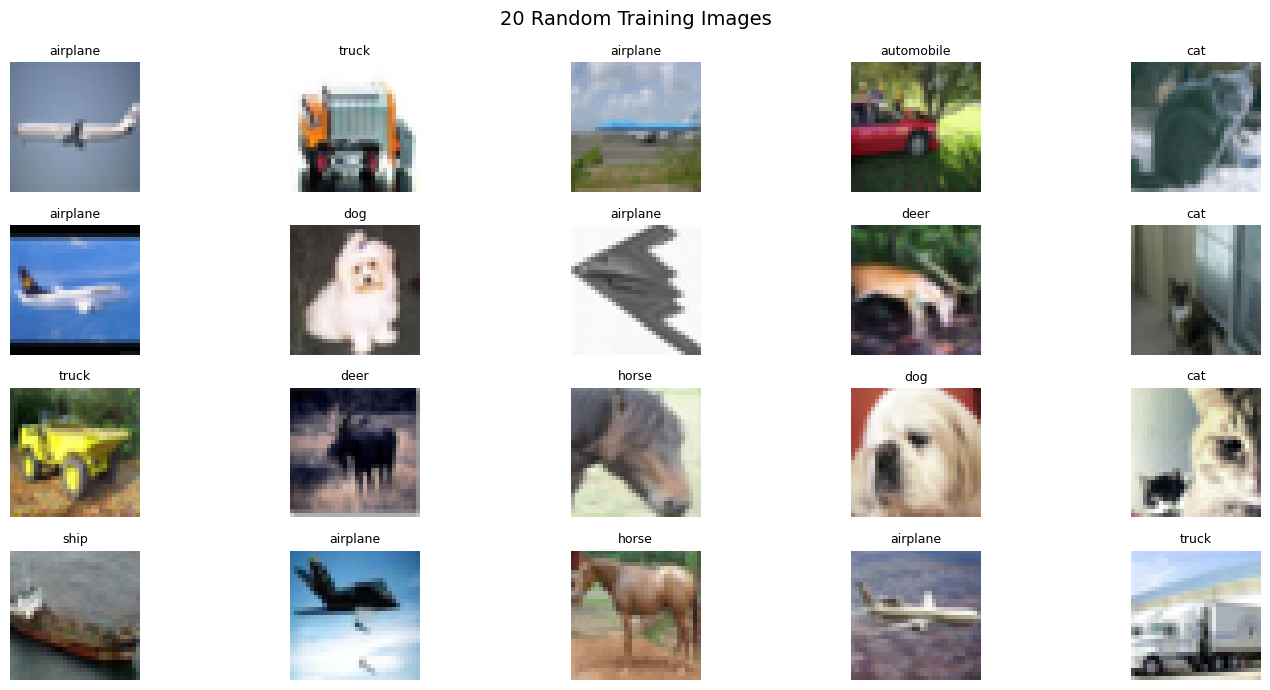

In [5]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

random_idx = np.random.choice(len(x_train_raw), size=20, replace=False)

plt.figure(figsize=(15, 7))
for i, idx in enumerate(random_idx):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train_raw[idx])
    plt.title(CLASS_NAMES[int(y_train_raw[idx][0])], fontsize=9)
    plt.axis('off')
plt.suptitle('20 Random Training Images', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Data Preprocessing
- **Normalization:** scale pixel values from `[0, 255]` to `[0, 1]`
- **One-hot encoding:** convert integer class labels to one-hot vectors for `categorical_crossentropy`

In [6]:
# Data normalization
x_train = x_train_raw.astype("float32") / 255
x_val = x_val_raw.astype("float32") / 255
x_test = x_test_raw.astype("float32") / 255

# One-hot encoding
NUM_CLASSES = 10
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_val = to_categorical(y_val_raw, NUM_CLASSES)
y_test = to_categorical(y_test_raw, NUM_CLASSES)

print("x_train range:", x_train.min(), "-", x_train.max())
print("y_train shape:", y_train.shape)

x_train range: 0.0 - 1.0
y_train shape: (40000, 10)


## 6. Model Architectures, Training, Curves & Saving
Three candidate CNN architectures are defined, trained, and saved below.

### 6.1 Functions to train and log models

In [7]:
from pathlib import Path

RESULTS_COLUMNS = [
    'model_name', 'notes', 'epochs', 'batch_size',
    'train_acc', 'train_loss',
    'val_acc', 'val_loss',
    'total_params',
    'train_time_min',
    'timestamp'
]

# Store results
RESULTS_CSV_PATH = 'cnn_model_results.csv'

if Path(RESULTS_CSV_PATH).exists():
  results_df = pd.read_csv(RESULTS_CSV_PATH)
else:
  results_df = pd.DataFrame(columns=RESULTS_COLUMNS)


def log_model_results(model, history, model_name, notes,
                       epochs, batch_size, train_time_sec, transfer_learning=False):
    """
    Record one model's results as a new row in the global results_df.

    Args:
        model: trained Keras model
        history: Keras History object (or dict) from model.fit
        test_metrics: (test_loss, test_acc) tuple from model.evaluate(test_ds)
        model_name (str): identifier, e.g. 'CNN_3conv_dropout'
        notes (str): anything worth remembering, e.g. 'added batchnorm, lr=1e-3'
        epochs (int): epochs actually trained (use len(history.history['loss']) if early stopping used)
        batch_size (int): batch size used
        train_time_sec (float): wall-clock training time in seconds
    """
    global results_df

    if transfer_learning:
      hist = {key: history[0].history[key] + history[1].history[key] for key in history[0].history}
    else:
      hist = history.history if hasattr(history, 'history') else history

    row = {
        'model_name': model_name,
        'notes': notes,
        'epochs': epochs,
        'batch_size': batch_size,
        'train_acc': hist['accuracy'][-1],
        'train_loss': hist['loss'][-1],
        'val_acc': hist['val_accuracy'][-1],
        'val_loss': hist['val_loss'][-1],
        'total_params': model.count_params(),
        'train_time_min': round(train_time_sec / 60, 2),
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

    # persist after every model, so partial progress isn't lost if the runtime crashes
    results_df.to_csv(RESULTS_CSV_PATH, index=False)

    print(f"Logged results for '{model_name}':")
    print(f"  Train Acc: {row['train_acc']:.4f} | Val Acc: {row['val_acc']:.4f} | "
          f"Time: {row['train_time_min']:.2f} min")


In [8]:
def plot_history(history, model_name='Model'):
    """
    Plot training vs validation accuracy and loss curves side by side.

    Args:
        history: a Keras History object (returned by model.fit) or a dict with the
                 same keys ('accuracy', 'val_accuracy', 'loss', 'val_loss')
        model_name (str): used in the plot title
    """
    hist = history.history if hasattr(history, 'history') else history

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist['accuracy'], label='Train Acc')
    axes[0].plot(hist['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [9]:
def train_and_log(model, train_ds, val_ds, model_name, notes='',
                   epochs=20, batch_size=64, callbacks=None):
    """
    Train a model, time it, plot curves, evaluate on test data, and log results.

    Returns:
        history: the Keras History object (useful if you want to inspect it further)
    """
    start_time = time.time()

    history = model.fit(
        train_ds[0], train_ds[1],
        validation_data=val_ds,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    train_time_sec = time.time() - start_time

    plot_history(history, model_name=model_name)

    #test_metrics = model.evaluate(test_ds[0], verbose=0)  # (loss, acc)

    actual_epochs = len(history.history['loss'])  # accounts for early stopping

    log_model_results(
        model=model,
        history=history,
        #test_metrics=test_metrics,
        model_name=model_name,
        notes=notes,
        epochs=actual_epochs,
        batch_size=batch_size,
        train_time_sec=train_time_sec
    )

    return history


In [10]:
def build_model(nlayers):
    model = tf.keras.Sequential(nlayers)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-7
)


## Model 1 - Baseline model

Simple Model with 1 convulutional layer.

In [12]:
# Clear memory
tf.keras.backend.clear_session()

# Define model 1
model_1 = [
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')
    ]

# Build model
model_1 = build_model(model_1)
model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4117 - loss: 1.6593 - val_accuracy: 0.5041 - val_loss: 1.4085
Epoch 2/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5390 - loss: 1.3115 - val_accuracy: 0.5662 - val_loss: 1.2563
Epoch 3/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5864 - loss: 1.1841 - val_accuracy: 0.5827 - val_loss: 1.1908
Epoch 4/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6106 - loss: 1.1152 - val_accuracy: 0.6092 - val_loss: 1.1381
Epoch 5/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6329 - loss: 1.0561 - val_accuracy: 0.6000 - val_loss: 1.1598
Epoch 6/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6548 - loss: 0.9963 - val_accuracy: 0.6293 - val_loss: 1.0931
Epoch 7/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6661 - loss: 0.9642 - val_accuracy: 0.6285 - val_loss: 1.0705
Epoch 8/20
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6812 - loss: 0.9209 - val_accuracy: 

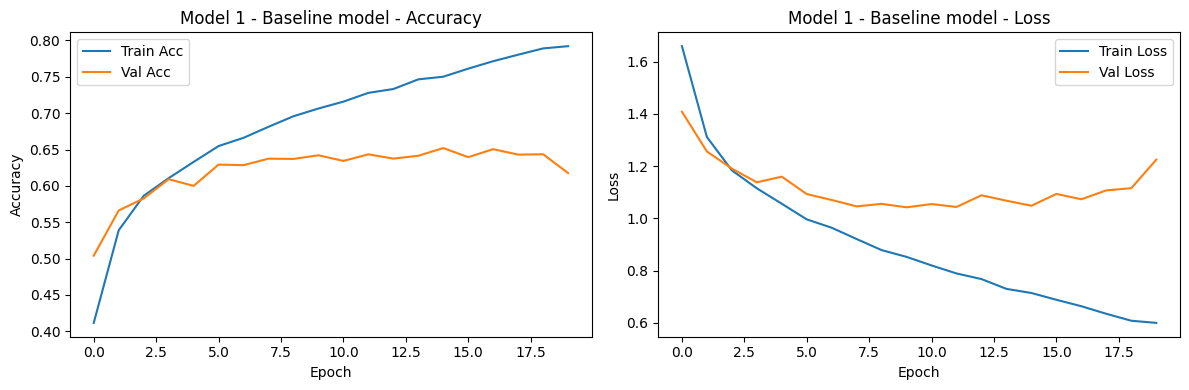

Logged results for 'Model 1 - Baseline model':
  Train Acc: 0.7921 | Val Acc: 0.6176 | Time: 0.88 min


/tmp/ipykernel_2576/1176785678.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)


In [13]:
results_model_1 = train_and_log(
    model=model_1,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 1 - Baseline model',
    notes='Ssimple model with 1 conv layer',
    epochs=20,
    batch_size=96,
    callbacks=None
)


## Model 2 - Deeper Model

- Model with 4 convulution blocks, batch notmalization and dropout
- Callbacks aded with 10 epochs and 96 batch size

In [14]:
# Clear memory
tf.keras.backend.clear_session()

# Define model_2
model_2 = [
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    Conv2D(512, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(10, activation='softmax')]

model_2 = build_model(model_2)
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,01

 Total params: 4,875,798 (18.60 MB)

 Trainable params: 4,873,878 (18.59 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step - accuracy: 0.3641 - loss: 1.7759 - val_accuracy: 0.2242 - val_loss: 2.3731 - learning_rate: 0.0010
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.5994 - loss: 1.1189 - val_accuracy: 0.5865 - val_loss: 1.2014 - learning_rate: 0.0010
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6896 - loss: 0.8813 - val_accuracy: 0.6603 - val_loss: 0.9805 - learning_rate: 0.0010
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7436 - loss: 0.7277 - val_accuracy: 0.6783 - val_loss: 0.9464 - learning_rate: 0.0010
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.7833 - loss: 0.6242 - val_accuracy: 0.7383 - val_loss: 0.7446 - learning_rate: 0.0010
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8095 - loss: 0.5480 - val_accuracy: 0.7798 - val_loss: 0.6535 - learning_rate: 0.0010
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8326 - l

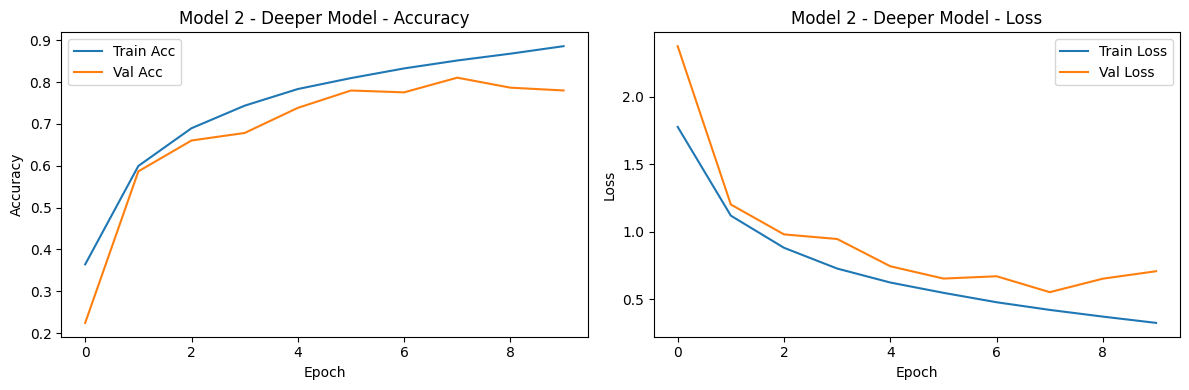

Logged results for 'Model 2 - Deeper Model':
  Train Acc: 0.8858 | Val Acc: 0.7799 | Time: 2.87 min


In [15]:
results_model_2 = train_and_log(
    model=model_2,
    train_ds=(x_train, y_train),
    val_ds=(x_val, y_val),
    #test_ds=(x_test, y_test),
    model_name='Model 2 - Deeper Model',
    notes='reduce batch size with calbacks',
    epochs=10,
    batch_size=96,
    callbacks=[early_stop, reduce_lr],
)

# Model 3 - MobilenetV2 Model

- Transfer learning model.
- Pretrained model MobilenetV2 with added layers.

In [ ]:
# Training done in mobilenetv2_transfer_model.ipynb
# load model 3
model_3 = tf.keras.models.load_model(MODEL_PATH+ 'mobilenetv2_transfer.keras')
model_3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 3, 64)       │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,580,960 (28.92 MB)

 Trainable params: 2,283,082 (8.71 MB)

 Non-trainable params: 731,712 (2.79 MB)

 Optimizer params: 4,566,166 (17.42 MB)

- prepare test data for transfer learning modle


In [25]:
IMG_SIZE = 96
BATCH_SIZE = 64
def preprocess(image, label, training=False):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    if training:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_crop(
            tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 8, IMG_SIZE + 8),
            size=[IMG_SIZE, IMG_SIZE, 3]
        )

    # Rescaling: MobileNetV2 expects preprocess_input (scales to [-1, 1])
    image = preprocess_input(image)
    return image, label


def make_dataset(x, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000)
    ds = ds.map(lambda img, lbl: preprocess(img, lbl, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = make_dataset(x_test_raw, y_test, training=False)


## Save all models

In [19]:
# --- Save model ---
model_1.save(MODEL_PATH+ 'model_1.keras')
model_2.save(MODEL_PATH+ 'model_2.keras')

## 7. Evaluation & Prediction on Test Set (All 3 Models)
Run each saved model on the held-out test set and collect predictions for comparison.

In [27]:
models_dict = {
    'Model 1 - Baseline': tf.keras.models.load_model(MODEL_PATH+ 'model_1.keras'),
    'Model 2 - Deeper': tf.keras.models.load_model(MODEL_PATH+ 'model_2.keras'),
    'Model 3 - MobilenetV2': tf.keras.models.load_model(MODEL_PATH+ 'mobilenetv2_transfer.keras'),
}

test_results = {}
predictions_dict = {}

for name, mdl in models_dict.items():
  if name == 'Model 3 - MobilenetV2':
    test_loss, test_acc = mdl.evaluate(test_ds, verbose=0)
    probs = mdl.predict(test_ds, batch_size=BATCH_SIZE, verbose=0)
  else:
    test_loss, test_acc = mdl.evaluate(x_test, y_test, verbose=0)
    probs = mdl.predict(x_test, verbose=0)
  pred_labels = np.argmax(probs, axis=1)

  test_results[name] = {'test_loss': test_loss, 'test_acc': test_acc}
  predictions_dict[name] = {'probs': probs, 'pred_labels': pred_labels}

  print(f"{name} -> Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

Model 1 - Baseline -> Test Acc: 0.6121 | Test Loss: 1.2387
Model 2 - Deeper -> Test Acc: 0.8089 | Test Loss: 0.5656
Model 3 - MobilenetV2 -> Test Acc: 0.8884 | Test Loss: 0.3332


# 8. Selected final model

**Model 3 - MobilenetV2** - pretrained mobilenetV2 model with added convolution layers

In [30]:
# --- Save model ---
models_dict['Model 3 - MobilenetV2'].save(MODEL_PATH+ 'final_model.keras')

## 9. Confusion Matrix (Selected Model)
Confusion matrix on the test set for the model chosen.

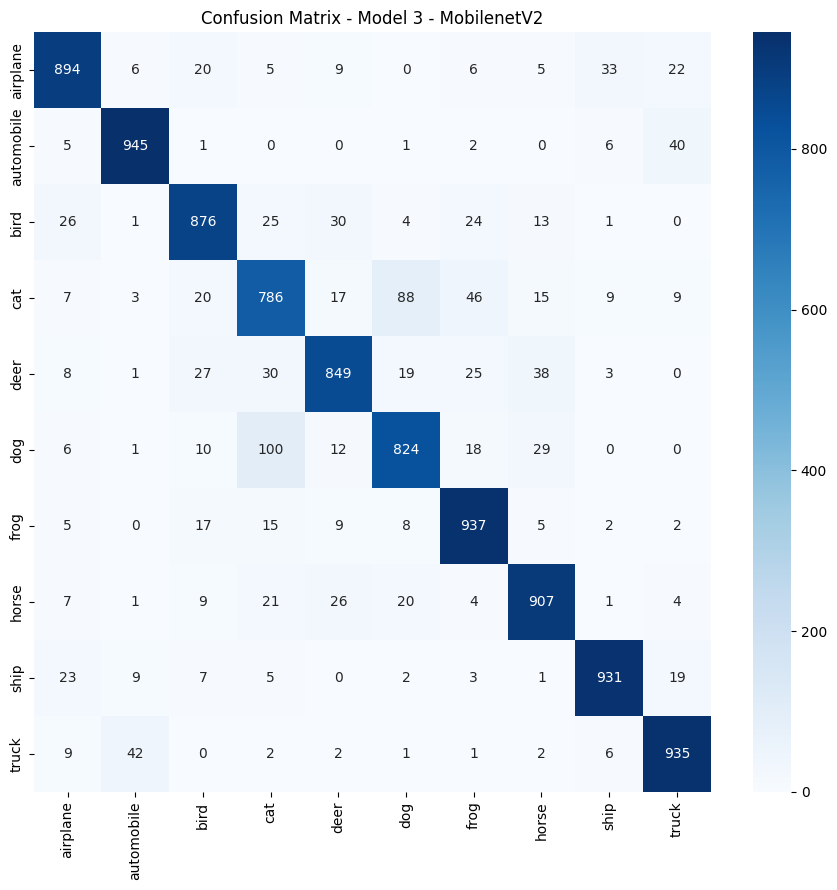

              precision    recall  f1-score   support

    airplane       0.90      0.89      0.90      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.89      0.88      0.88      1000
         cat       0.79      0.79      0.79      1000
        deer       0.89      0.85      0.87      1000
         dog       0.85      0.82      0.84      1000
        frog       0.88      0.94      0.91      1000
       horse       0.89      0.91      0.90      1000
        ship       0.94      0.93      0.93      1000
       truck       0.91      0.94      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [43]:
SELECTED_MODEL_NAME = 'Model 3 - MobilenetV2'
selected_pred_labels = predictions_dict[SELECTED_MODEL_NAME]['pred_labels']
selected_probs = predictions_dict[SELECTED_MODEL_NAME]['probs']

y_test_labels = y_test_raw.ravel()

cm = confusion_matrix(y_test_labels, selected_pred_labels)
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - {SELECTED_MODEL_NAME}')
plt.tight_layout()
plt.show()

print(classification_report(y_test_labels, selected_pred_labels, target_names=CLASS_NAMES))


- Overall precision of model is good. However, there is confusion between cat and dog

## 10. Misclassified Images (Selected Model)
Plot 10 misclassified test images with their true and predicted labels.

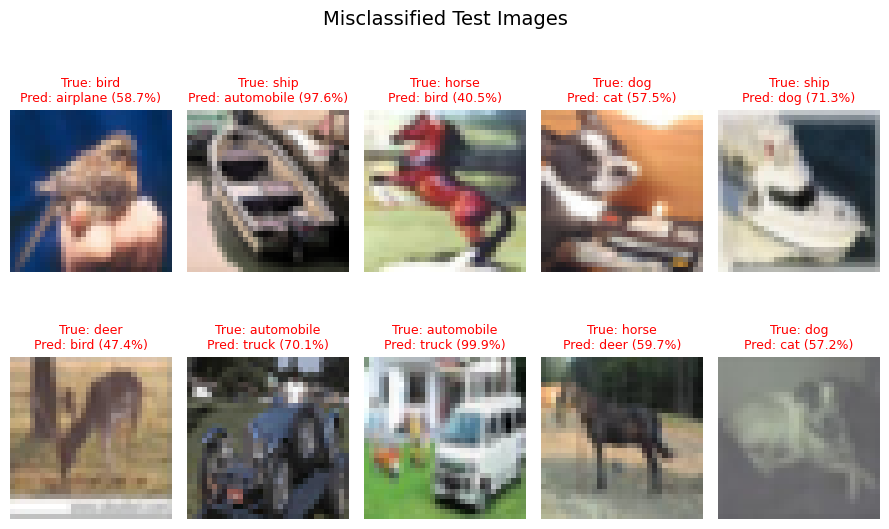

In [45]:
misclassified_idx = np.where(selected_pred_labels != y_test_labels)[0]
sample_idx = np.random.choice(misclassified_idx, size=10, replace=False)

plt.figure(figsize=(9, 6))
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.axis('off')
    true_name = CLASS_NAMES[y_test_labels[idx]]
    pred_name = CLASS_NAMES[selected_pred_labels[idx]]
    conf = selected_probs[idx][selected_pred_labels[idx]] * 100
    plt.title(f"True: {true_name}\nPred: {pred_name} ({conf:.1f}%)", fontsize=9, color='red')
plt.suptitle('Misclassified Test Images', fontsize=14)
plt.tight_layout()
plt.show()


- Based on the image, the model confuses truck, ships with automobile which is logicall given they come the same class.
- dog and cat are also confused, which is noticed in the confusion matrix as well.

## 11. Final Inference / Conclusion

**Summary of approach:**

- 3 architechtures where trained and evaluated. One simple baseline, one deeper model with many layers and one pretrained model with added layers.

**Final model performance:**

- The Transfer learning model performed best with test accuracy ~ 88% and loss of 0.33
- The model genrealised good.


**Key learnings / challenges:**
- Data augmentation : not useful for this dataset. Very low performance noticed.
- Image resizing : required longer train time. Also, low performance was noticed.

In [48]:
final_acc = test_results[SELECTED_MODEL_NAME]['test_acc']
final_loss = test_results[SELECTED_MODEL_NAME]['test_loss']

print(f"{SELECTED_MODEL_NAME} -> Test Acc: {final_acc:.4f} | Test Loss: {final_loss:.4f}")

Model 3 - MobilenetV2 -> Test Acc: 0.8884 | Test Loss: 0.3332
